In [0]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from delta.tables import DeltaTable
import matplotlib.pyplot as plt

In [0]:

base_path = "file:/Workspace/Users/azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com"

customer_df=spark.read.csv(f"{base_path}/customers.csv", header=True, inferSchema=True)

product_df=spark.read.csv(f"{base_path}/products.csv", header=True, inferSchema=True)

orders_df=spark.read.csv(f"{base_path}/orders.csv", header=True, inferSchema=True)

preferences_df= spark.read.option("multiLine","true").json(f"{base_path}/preferences.json")


In [0]:
customer_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()
product_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)



In [0]:
customer_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/customers")

product_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/products")

orders_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/orders")

preferences_df.write.mode("overwrite").format("delta").save("dbfs:/bronze/preferences")

In [0]:
customer_df.show()

product_df.show()

orders_df.show()

preferences_df.show(truncate=False)

+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronic

In [0]:
flat_df=preferences_df.select(
    "customer_id",
    col("loyalty.points").alias("loyalty_points"),
    col("loyalty.tier").alias("loyalty_tier"),
    "preferred_channel")
                              
flat_df.show()

+-----------+--------------+------------+-----------------+
|customer_id|loyalty_points|loyalty_tier|preferred_channel|
+-----------+--------------+------------+-----------------+
|       C101|          1200|        Gold|           Online|
|       C102|           700|      Silver|            Store|
|       C104|          2200|    Platinum|           Online|
|       C108|          1500|        Gold|       Mobile App|
+-----------+--------------+------------+-----------------+



In [0]:
customer_pref_df = customer_df.join(
    flat_df,"customer_id","left"
)

In [0]:
orders_customer_df = orders_df.join(
    customer_pref_df,"customer_id","left"
)

In [0]:
retail_df = orders_customer_df.join(
    product_df,"product_id","left"
)

retail_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|           700|      Silver|            Store|      Mobile|Electronics|     25000|
|      P103|       C

In [0]:

retail_df = retail_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

retail_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|           700|      Silver|            Store|      Mobile|Electronics|

In [0]:
retail_df = retail_df.withColumn(
    "order_month",
    month("order_date")
)

retail_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|order_month|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|          6|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|           700|      Si

In [0]:
retail_df = retail_df.withColumn(
    "customer_segment",
    when(
        col("customer_type")=="Premium",
        "High Value"
    ).otherwise("Standard Value")
)

retail_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
retail_df=retail_df.na.fill({"loyalty_tier": "Unknown",
                   "preferred_channel": "Unknown", "loyalty_points": 0})

In [0]:
retail_df.write.mode("overwrite").format("delta").save("dbfs:/silver/retail")

In [0]:
retail_df.createOrReplaceTempView("retail")

In [0]:
spark.sql("""
SELECT
SUM(revenue) AS total_revenue
FROM retail
""").show()

+-------------+
|total_revenue|
+-------------+
|       336000|
+-------------+



In [0]:
spark.sql("""
SELECT
city,SUM(revenue) AS total_revenue
FROM retail
GROUP BY city
""").show()

+---------+-------------+
|     city|total_revenue|
+---------+-------------+
|    Delhi|        89000|
|  Chennai|        18000|
|    Kochi|        15000|
|Hyderabad|       135000|
|Bangalore|        50000|
|     Pune|         8000|
|   Mumbai|        21000|
+---------+-------------+



In [0]:
spark.sql("""
SELECT
category,SUM(revenue) AS total_revenue
FROM retail
GROUP BY category
""").show()

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|       250000|
|  Furniture|        45000|
|    Fashion|        41000|
+-----------+-------------+



In [0]:
spark.sql("""
SELECT
customer_name,
SUM(revenue) total_revenue
FROM retail
GROUP BY customer_name
ORDER BY total_revenue DESC
""").show()

+-------------+-------------+
|customer_name|total_revenue|
+-------------+-------------+
| Rahul Sharma|        90000|
|  Sneha Patel|        89000|
|  Priya Reddy|        50000|
|  Arjun Verma|        45000|
|   Amit Kumar|        21000|
|   Farhan Ali|        18000|
|   Meera Nair|        15000|
|   Neha Singh|         8000|
+-------------+-------------+



In [0]:
spark.sql("""
SELECT * FROM retail
WHERE status='Completed'
""").display()

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,loyalty_points,loyalty_tier,preferred_channel,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,1200,Gold,Online,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,700,Silver,Store,Mobile,Electronics,25000,50000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,2200,Platinum,Online,Table,Furniture,12000,24000,6,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,0,Unknown,Unknown,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,0,Unknown,Unknown,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,1500,Gold,Mobile App,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,1200,Gold,Online,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,2200,Platinum,Online,Laptop,Electronics,65000,65000,6,High Value


In [0]:
customer_window = Window.orderBy(col("revenue").desc())

product_revenue = retail_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

product_revenue.withColumn(
    "rank",
    rank().over(customer_window)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-------+----+
|product_name|revenue|rank|
+------------+-------+----+
|      Laptop| 130000|   1|
|      Mobile|  75000|   2|
|          TV|  45000|   3|
|       Table|  24000|   4|
|       Chair|  21000|   5|
|       Shoes|  18000|   6|
|         Bag|  15000|   7|
|       Watch|   8000|   8|
+------------+-------+----+



In [0]:

customer_revenue = retail_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("total_revenue")
)

customer_rank = customer_revenue.withColumn(
    "rank",
    rank().over(Window.orderBy(col("total_revenue").desc()))
)

customer_rank.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------+-------------+----+
|customer_name|total_revenue|rank|
+-------------+-------------+----+
| Rahul Sharma|        90000|   1|
|  Sneha Patel|        89000|   2|
|  Priya Reddy|        50000|   3|
|  Arjun Verma|        45000|   4|
|   Amit Kumar|        21000|   5|
|   Farhan Ali|        18000|   6|
|   Meera Nair|        15000|   7|
|   Neha Singh|         8000|   8|
+-------------+-------------+----+



In [0]:
customer_rank.filter(
    col("rank")<=3
).show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------+-------------+----+
|customer_name|total_revenue|rank|
+-------------+-------------+----+
| Rahul Sharma|        90000|   1|
|  Sneha Patel|        89000|   2|
|  Priya Reddy|        50000|   3|
+-------------+-------------+----+



In [0]:
category_window = Window.partitionBy("category").orderBy(desc("revenue"))

category_rank = retail_df.withColumn(
    "rank",
    rank().over(category_window)
)

category_rank.filter(
    col("rank")==1
).show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+----+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|     state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|order_month|customer_segment|rank|
+----------+-----------+--------+----------+--------+---------+-------------+---------+----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+----+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad| Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|          6|      High Value|   1|
|      P101|       C104|   O1010|2026-06-05|       1

In [0]:
date_window = Window.orderBy("order_date")

retail_df.withColumn(
    "running_revenue",
    sum("revenue").over(date_window)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+---------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|order_month|customer_segment|running_revenue|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+---------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|          6|      High Value|         115000|
|   

In [0]:
retail_df.write.mode("overwrite").format("delta").save("dbfs:/delta/retail")

In [0]:
retail_df.write.mode("overwrite").format("delta").saveAsTable("retail_table")

In [0]:
%sql
CREATE TABLE retail_sql
USING DELTA
AS
SELECT * FROM retail_table;

num_affected_rows,num_inserted_rows


In [0]:
%sql DESCRIBE HISTORY retail_table;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-22T08:26:56.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936738),6aeb01c4-efef-4d76-abcf-dc51ab9f4744,0622-072159-yoc5zf8l-v2n,0,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 5847, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5847)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T08:26:46.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936738),678b8d17-5d44-4dd0-9239-a9a46d55bfd0,0622-072159-yoc5zf8l-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5847)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.read.format("delta").option("versionAsOf",0).load("dbfs:/delta/retail").show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|loyalty_points|loyalty_tier|preferred_channel|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+--------------+------------+-----------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|          1200|        Gold|           Online|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Pri

In [0]:
updated_customer = spark.createDataFrame(
[("C101","Rahul Sharma","Mumbai","Maharashtra","Premium")],
customer_df.columns
)

delta_table = DeltaTable.forPath(spark, "dbfs:/bronze/customers")

delta_table.alias("target").merge(
updated_customer.alias("source"),
"target.customer_id=source.customer_id"
).whenMatchedUpdateAll().execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql DESCRIBE HISTORY retail_table;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-22T08:26:56.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936738),6aeb01c4-efef-4d76-abcf-dc51ab9f4744,0622-072159-yoc5zf8l-v2n,0,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 5847, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5847)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T08:26:46.000Z,148916151530801,azuser7222_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4449026334936738),678b8d17-5d44-4dd0-9239-a9a46d55bfd0,0622-072159-yoc5zf8l-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5847)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql OPTIMIZE retail_table;

path,metrics
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/4fbace31-3f5c-4c81-9849-f7823a3c18e2,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782117488885, 1782117489380, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql OPTIMIZE retail_table
ZORDER BY(city);

path,metrics
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/4fbace31-3f5c-4c81-9849-f7823a3c18e2,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5847), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782117841090, 1782117841837, 8, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql VACUUM retail_table RETAIN 168 HOURS;

path
abfss://unity-catalog-storage@dbstoragedaqeulmliu5fu.dfs.core.windows.net/7405614176101619/__unitystorage/catalogs/e4fa79a1-fc33-4aad-bcae-881d69b5f5ad/tables/4fbace31-3f5c-4c81-9849-f7823a3c18e2


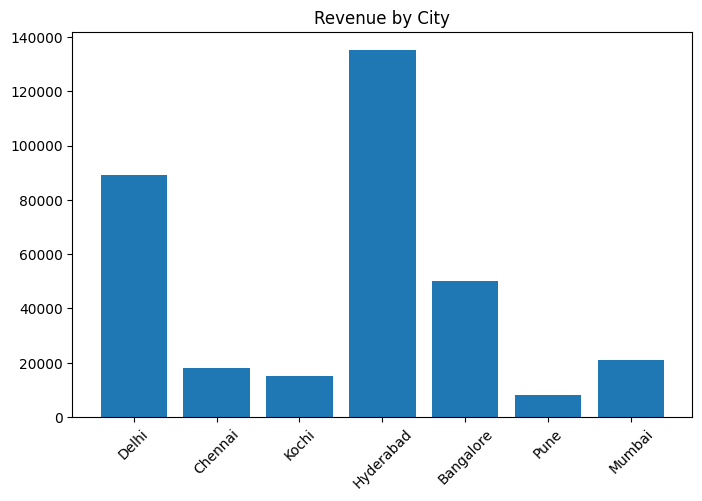

In [0]:
city_df = retail_df.groupBy("city").agg(sum("revenue").alias("Revenue"))

pd_df = city_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pd_df.city,pd_df.Revenue)
plt.xticks(rotation=45)
plt.title("Revenue by City")
plt.show()

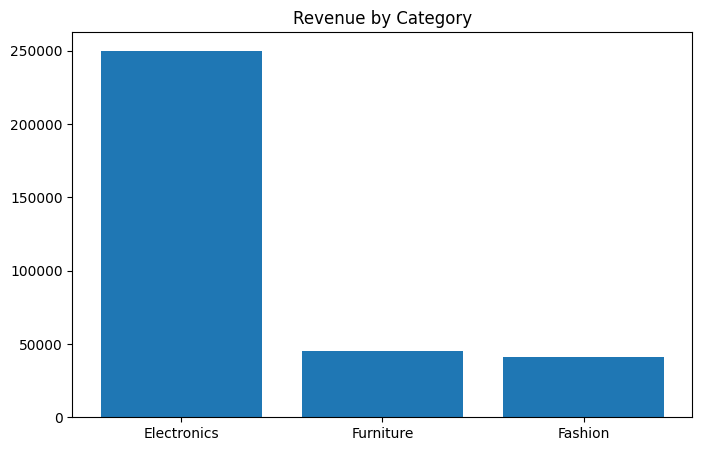

In [0]:
category_df = retail_df.groupBy("category").agg(sum("revenue").alias("Revenue"))

pd_df = category_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pd_df.category,pd_df.Revenue)
plt.title("Revenue by Category")
plt.show()

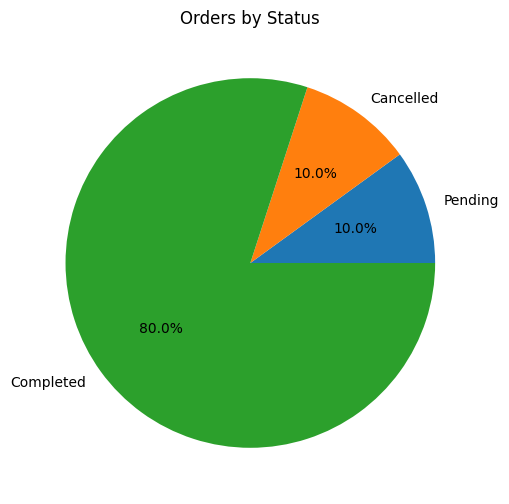

In [0]:
status_df = retail_df.groupBy("status").count()

pd_df = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(pd_df["count"],labels=pd_df["status"],autopct="%1.1f%%")
plt.title("Orders by Status")
plt.show()

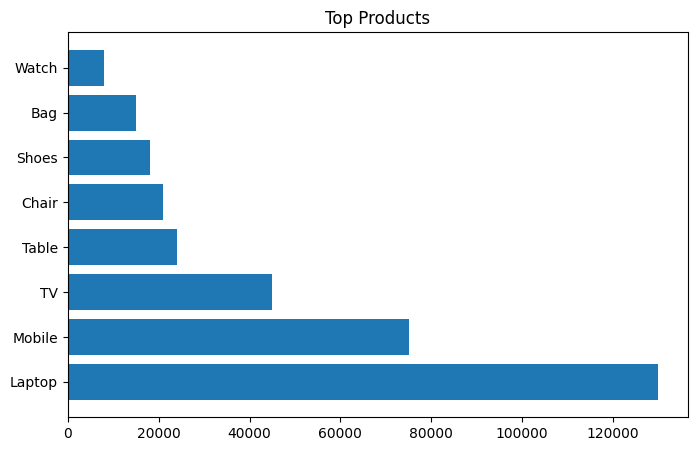

In [0]:
product_df = retail_df.groupBy("product_name").agg(sum("revenue").alias("Revenue"))

pd_df = product_df.orderBy(desc("Revenue")).toPandas()

plt.figure(figsize=(8,5))
plt.barh(pd_df.product_name,pd_df.Revenue)
plt.title("Top Products")
plt.show()

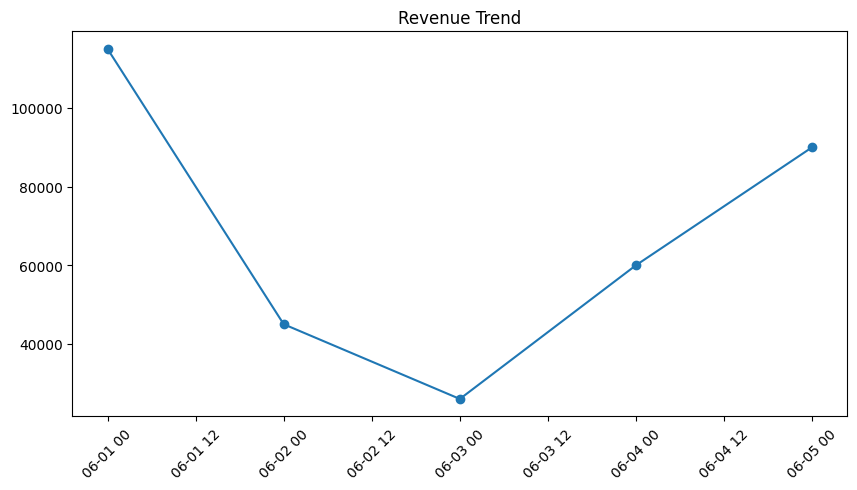

In [0]:
trend_df = retail_df.groupBy("order_date").agg(sum("revenue").alias("Revenue"))

pd_df = trend_df.orderBy("order_date").toPandas()

plt.figure(figsize=(10,5))
plt.plot(pd_df.order_date,pd_df.Revenue,marker="o")
plt.xticks(rotation=45)
plt.title("Revenue Trend")
plt.show()

In [0]:
retail_df.write.mode("overwrite").saveAsTable("managed_retail")

In [0]:
%sql
CREATE OR REPLACE TABLE external_retail
USING DELTA
AS
SELECT * FROM managed_retail;

num_affected_rows,num_inserted_rows


In [0]:
retail_df.createOrReplaceTempView("retail_temp")

In [0]:
retail_df.createOrReplaceTempView("retail_global")